# Portfolio Assessment3
## Duc Thuan Tran 104330455

In [2]:
import os
import sys

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import pickle
 

In [4]:
df = pd.read_csv('vegemite.csv')

# Step 1: Data Preparation

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15237 entries, 0 to 15236
Data columns (total 47 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   FFTE Feed tank level SP        15237 non-null  float64
 1   FFTE Production solids SP      15237 non-null  float64
 2   FFTE Steam pressure SP         15237 non-null  float64
 3   TFE Out flow SP                15237 non-null  float64
 4   TFE Production solids SP       15237 non-null  float64
 5   TFE Vacuum pressure SP         15237 non-null  float64
 6   TFE Steam pressure SP          15237 non-null  float64
 7   TFE Steam temperature SP       15237 non-null  float64
 8   FFTE Feed flow SP              15237 non-null  float64
 9   FFTE Out steam temp SP         15237 non-null  float64
 10  Extract tank Level             15237 non-null  float64
 11  Extract tank Out flow PV       15237 non-null  float64
 12  FFTE Discharge density         15237 non-null 

In [7]:
df.head()

,FFTE Feed tank level SP,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,TFE Steam temperature SP,FFTE Feed flow SP,FFTE Out steam temp SP,...,TFE Out flow PV,TFE Product out temperature,TFE Production solids PV,TFE Production solids density,TFE Steam pressure PV,TFE Steam temperature,TFE Tank level,TFE Temperature,TFE Vacuum pressure PV,Class
0,50.0,40.74,125.0,2897.65,69.0,-80.00,125.0,80.0,10130.0,49.88,...,2577.82,0.0,62.87,1.19,125.03,72.68,83.68,71.0,-77.74,1
1,50.0,40.74,125.0,2897.65,69.0,-79.45,125.0,80.0,10130.0,49.88,...,1551.88,0.0,67.98,1.19,125.03,64.66,82.95,69.0,-79.49,1
2,50.0,40.74,125.0,2897.65,69.0,-71.54,125.0,80.0,10130.0,49.88,...,1564.85,0.0,70.38,1.19,124.71,65.63,82.77,72.0,-75.28,1
3,50.0,40.74,125.0,2897.65,69.0,-68.44,125.0,80.0,10130.0,49.88,...,1512.97,0.0,69.18,1.19,124.71,74.35,82.55,76.0,-69.65,1
4,50.0,39.00,90.0,2694.62,64.0,-80.00,120.0,80.0,9300.0,49.88,...,1795.72,0.0,41.14,0.90,119.91,70.82,83.96,71.0,-75.28,1


In [8]:
df.shape

(15237, 47)

In [9]:
df.tail()

,FFTE Feed tank level SP,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,TFE Steam temperature SP,FFTE Feed flow SP,FFTE Out steam temp SP,...,TFE Out flow PV,TFE Product out temperature,TFE Production solids PV,TFE Production solids density,TFE Steam pressure PV,TFE Steam temperature,TFE Tank level,TFE Temperature,TFE Vacuum pressure PV,Class
15232,50.0,41.5,135.0,1925.3,71.0,-63.12,120.0,80.0,9400.0,50.4,...,4532.43,0.0,70.84,1.25,119.91,73.84,83.28,74.0,-73.50,2
15233,50.0,41.5,135.0,1925.3,71.0,-69.46,120.0,80.0,9400.0,50.4,...,2680.29,0.0,70.09,1.25,119.91,73.46,83.72,73.0,-75.64,2
15234,50.0,41.5,135.0,1925.3,71.0,-68.95,120.0,80.0,9400.0,50.4,...,1859.92,0.0,70.09,1.25,119.91,63.73,84.20,72.0,-76.32,2
15235,50.0,41.5,135.0,1925.3,71.0,-62.23,120.0,80.0,9400.0,50.4,...,2590.14,0.0,70.09,1.25,119.91,71.21,86.23,70.0,-77.39,2
15236,50.0,41.5,135.0,1925.3,71.0,-52.04,120.0,80.0,9400.0,50.4,...,2590.14,0.0,70.09,1.25,119.91,71.21,86.23,70.0,-77.03,2


In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [11]:
df['Class'].value_counts()

Class
2    7548
1    5047
0    2642
Name: count, dtype: int64

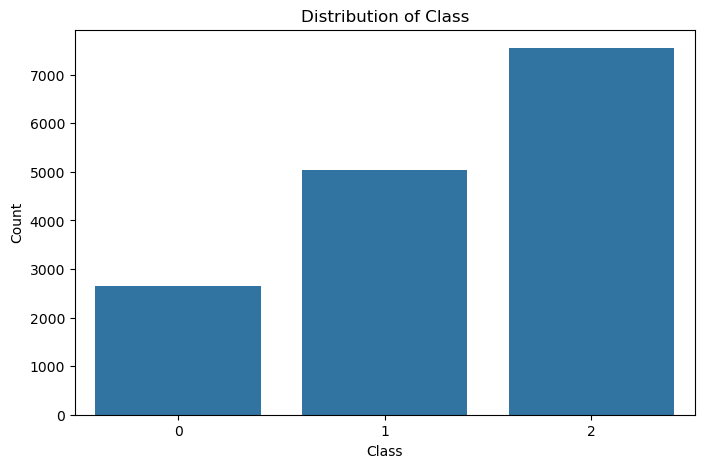

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(data = df, x='Class')
plt.title("Distribution of Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [13]:
# 1. Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Randomly take out 1000 data points with balanced classes
test_samples = []
class_distribution = {0:334, 1:333, 2:333}

for class_value, sample_count in class_distribution.items():
    class_rows = df[df['Class'] == class_value]

    if len(class_rows) < sample_count:
        print(f"Warning: Not enough samples for class {class_value}. Only {len(class_rows)} available.")
        sample_count = len(class_rows)

    selected = class_rows.sample(n=sample_count, random_state=42)
    test_samples.append(selected)
    print(f"Selected {sample_count} samples from class {class_value}")

    df = df[~df.index.isin(selected.index)]

test_df = pd.concat(test_samples).reset_index(drop=True)

train_df = df.reset_index(drop=True)

Selected 334 samples from class 0
Selected 333 samples from class 1
Selected 333 samples from class 2


In [14]:
test_df.shape

(1000, 47)

In [15]:
train_df.shape

(14237, 47)

## Features Constructing 

### 1. Checking for constant value columns

In [18]:
constant_cols = [col for col in train_df.columns if train_df[col].nunique() == 1]

if constant_cols:
    # Remove constant columns
    train_df = train_df.drop(columns=constant_cols)
    test_df = test_df.drop(columns=constant_cols)

constant_cols

['TFE Steam temperature SP', 'TFE Product out temperature']

### 2. Checking for column with few integer values


In [20]:
few_integer_cols = []
for col in train_df.columns:
    if train_df[col].dtype in ['int64', 'float64']:
        unique_values = train_df[col].nunique()
        if unique_values < 10 and col != 'Class':
            few_integer_cols.append(col)

# Convert integer columns to category
for col in few_integer_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')
    print(f"Converted {col} to categorical")
 

Converted FFTE Feed tank level SP to categorical
Converted FFTE Pump 1 to categorical
Converted FFTE Pump 1 - 2 to categorical
Converted FFTE Pump 2 to categorical
Converted TFE Motor speed to categorical


### 3. Checking for class balanced distribution


In [22]:
# 3. Checking for class balanced distribution
class_counts = train_df['Class'].value_counts()

class_counts

Class
2    7215
1    4714
0    2308
Name: count, dtype: int64

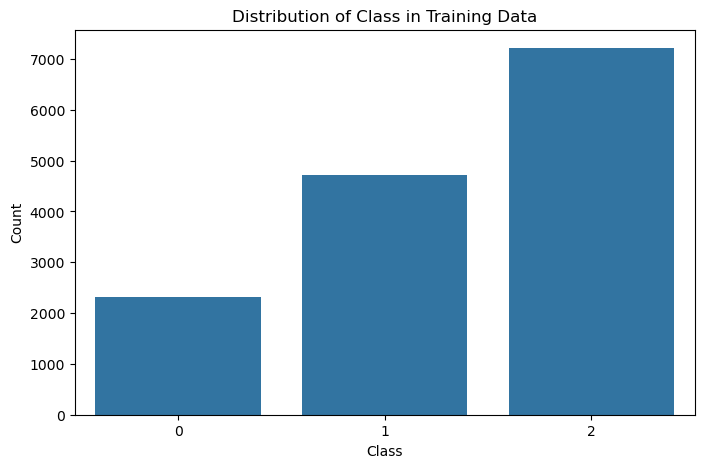

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(data = train_df, x='Class')
plt.title("Distribution of Class in Training Data")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [24]:
# Choosing the methods base on the ratio performance
min_class_count = class_counts.min()
max_class_count = class_counts.max()
imbalance_ratio = min_class_count / max_class_count

print(f"Imbalance ratio (min/max): {imbalance_ratio:.4f}")

BALANCED_THRESHOLD = 0.8
MODERATE_IMBALANCE = 0.5
SEVERE_IMBALANCE = 0.2

if imbalance_ratio >= BALANCED_THRESHOLD:
    print("Classes are fairly balanced. No resampling needed.")
    resampling_method = None
elif imbalance_ratio >= MODERATE_IMBALANCE:
    print("Moderate class imbalance detected. Will use class weights in model training.")
    class_weights = {i: len(train_df) / (len(np.unique(train_df['Class'])) * count) 
                      for i, count in enumerate(class_counts)}
    print(f"Class weights: {class_weights}")
    resampling_method = "class_weights"
elif imbalance_ratio >= SEVERE_IMBALANCE:
    print("Significant class imbalance detected. Will apply SMOTE oversampling.")
    resampling_method = "smote"
else:
    print("Severe class imbalance detected. Will apply combination of undersampling and SMOTE.")
    resampling_method = "undersampling+smote"

 

Imbalance ratio (min/max): 0.3199
Significant class imbalance detected. Will apply SMOTE oversampling.


#### SMOTE

In [26]:
X = train_df.drop('Class', axis=1)
y = train_df['Class']

print("Class distribution before resampling:")
print(y.value_counts())

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Create a new DataFrame with the resampled data
resampled_df = pd.DataFrame(X_resampled, columns=X.columns)
resampled_df['Class'] = y_resampled

print("Class distribution after resampling:")
print(pd.Series(y_resampled).value_counts())

train_df = resampled_df

Class distribution before resampling:
Class
2    7215
1    4714
0    2308
Name: count, dtype: int64
Class distribution after resampling:
Class
2    7215
0    7215
1    7215
Name: count, dtype: int64


### 4. Checking for composite features through exploration

In [28]:
train_df.corr()

,FFTE Feed tank level SP,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,FFTE Feed flow SP,FFTE Out steam temp SP,Extract tank Level,...,TFE Motor speed,TFE Out flow PV,TFE Production solids PV,TFE Production solids density,TFE Steam pressure PV,TFE Steam temperature,TFE Tank level,TFE Temperature,TFE Vacuum pressure PV,Class
FFTE Feed tank level SP,1.000000,-0.091925,-0.244767,-0.047703,0.312707,-0.272909,0.564166,-0.523272,0.032591,0.072949,...,0.296369,-0.143039,0.266060,0.053475,0.206295,0.030357,0.084839,-0.025384,-0.267474,-0.075945
FFTE Production solids SP,-0.091925,1.000000,0.036744,0.552262,0.316578,0.197538,-0.095635,0.266580,0.082666,-0.025623,...,-0.054974,-0.006706,0.076988,0.047018,-0.018415,0.062681,-0.041445,0.067010,0.075994,0.134056
FFTE Steam pressure SP,-0.244767,0.036744,1.000000,-0.065921,-0.045788,-0.107372,-0.295254,0.277625,0.074718,-0.059440,...,-0.161491,0.047770,-0.169390,-0.053846,-0.127254,-0.040058,-0.104079,-0.005122,0.144156,0.099521
TFE Out flow SP,-0.047703,0.552262,-0.065921,1.000000,0.278106,0.272331,-0.066114,0.309181,0.014353,0.045048,...,-0.073306,0.040422,0.009211,-0.011188,-0.021794,0.057906,-0.061985,0.049072,0.074671,0.176178
TFE Production solids SP,0.312707,0.316578,-0.045788,0.278106,1.000000,-0.164310,0.385506,-0.301060,0.024331,0.015245,...,0.016686,-0.024611,0.068241,0.010475,0.044058,0.032216,-0.042448,0.013151,-0.012161,0.020826
TFE Vacuum pressure SP,-0.272909,0.197538,-0.107372,0.272331,-0.164310,1.000000,-0.241671,0.303772,0.013944,-0.004955,...,-0.113871,0.071447,-0.088325,-0.015079,-0.110576,0.043231,0.001082,0.067584,0.143266,0.113435
TFE Steam pressure SP,0.564166,-0.095635,-0.295254,-0.066114,0.385506,-0.241671,1.000000,-0.838869,-0.042486,0.023240,...,0.332227,-0.166993,0.328011,0.123794,0.256870,0.083389,0.064548,0.038719,-0.277771,-0.022117
FFTE Feed flow SP,-0.523272,0.266580,0.277625,0.309181,-0.301060,0.303772,-0.838869,1.000000,0.047579,-0.013352,...,-0.308074,0.168568,-0.292532,-0.106042,-0.235656,-0.049460,-0.074414,-0.002708,0.274173,0.112202
FFTE Out steam temp SP,0.032591,0.082666,0.074718,0.014353,0.024331,0.013944,-0.042486,0.047579,1.000000,-0.017095,...,-0.026919,0.037660,-0.008530,-0.058527,-0.047594,-0.023125,-0.042198,-0.027986,0.027829,-0.053125
Extract tank Level,0.072949,-0.025623,-0.059440,0.045048,0.015245,-0.004955,0.023240,-0.013352,-0.017095,1.000000,...,0.195686,-0.122099,0.124819,-0.087600,0.119818,0.041924,0.113860,0.003142,-0.152732,-0.058090


In [29]:
corr = train_df.select_dtypes(include=[np.number]).corr()

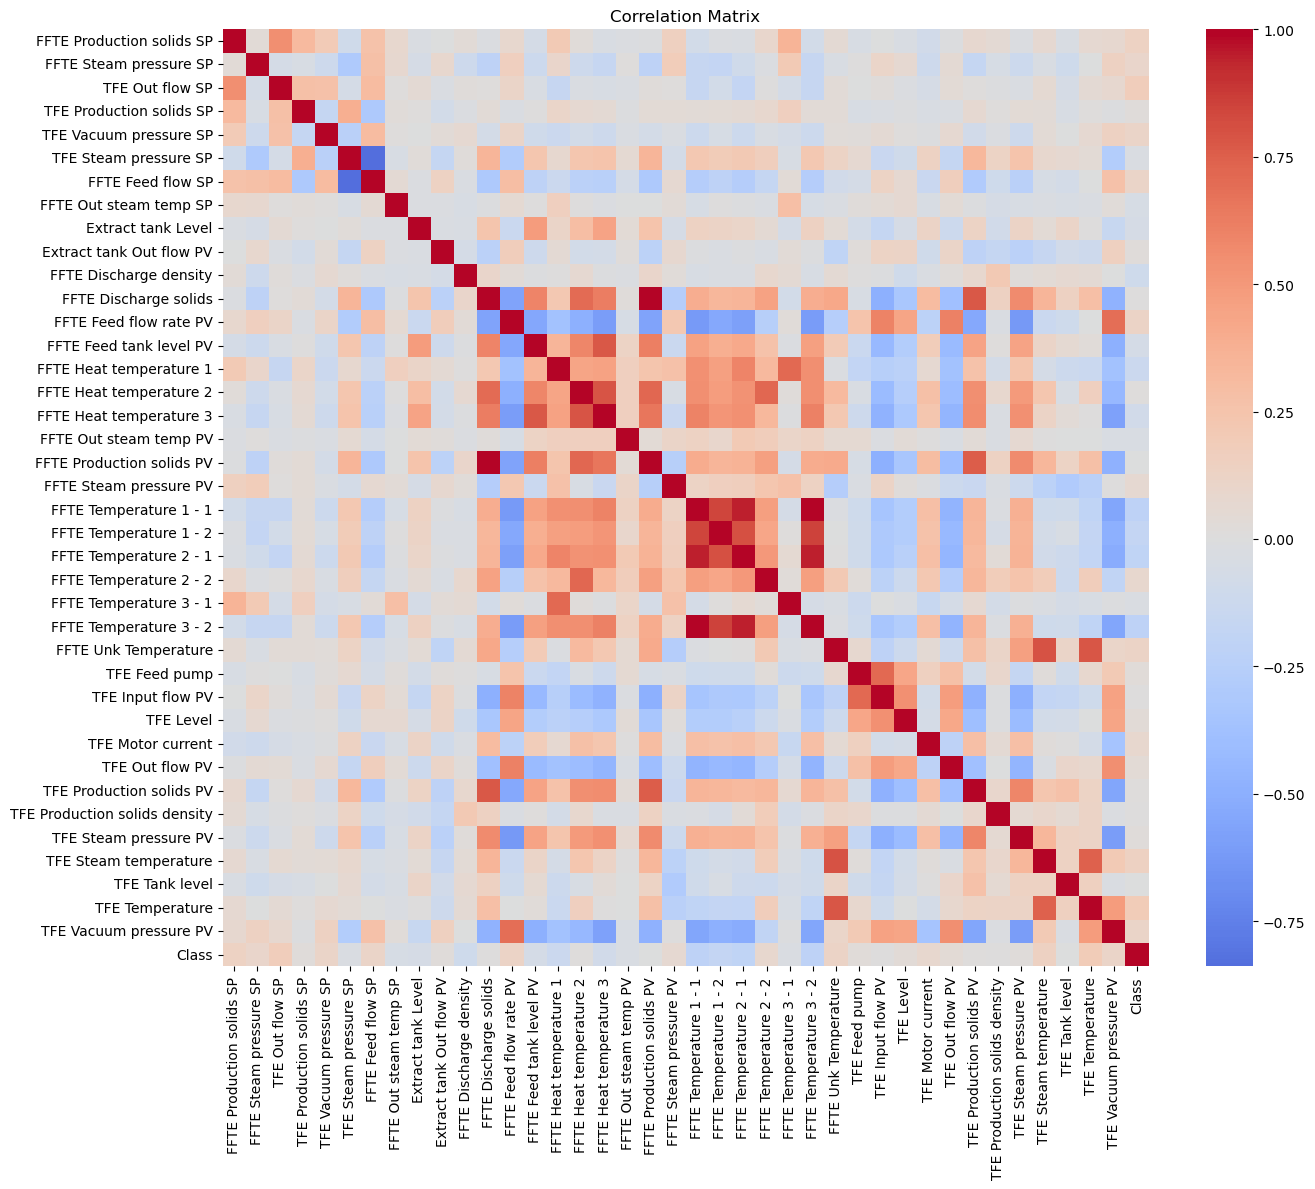

In [30]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.tight_layout()



In [31]:
# Average temperature 
train_df['FFTE_avg_temperature'] = (train_df['FFTE Temperature 1 - 1'] + 
                                   train_df['FFTE Temperature 1 - 2'] +
                                   train_df['FFTE Temperature 2 - 1'] +
                                   train_df['FFTE Temperature 3 - 2'] ) / 4

# Ratio between feed flow and steam pressure setpoints  
train_df['flow_pressure_ratio'] = train_df['FFTE Feed flow SP'] / train_df['FFTE Steam pressure SP']

# Deviation between actual and target solids 
train_df['FFTE_Production_solids_deviation'] = train_df['FFTE Production solids PV'] - train_df['FFTE Production solids SP']

### 5. Checking the final features count

In [33]:
num_features = len([col for col in train_df.columns if col != 'Class'])

print(num_features)

47


# Step 2: Feature Selection, Model Training and Evaluation

### 6. Feature Selection with SelectKBest

In [36]:
X_train = train_df.drop("Class", axis=1)
y_train = train_df["Class"]
X_test = test_df.drop("Class", axis=1)
y_test = test_df["Class"]

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Score' : selector.scores_
})

feature_scores = feature_scores.sort_values('Score', ascending = False)

In [37]:
top_features = feature_scores.head(20)['Feature'].values
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

### 7. Multiple Models Traning & 8. Models Evaluating & 9. Model Comparing 

In [69]:
# Model training and evaluation
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}
model_performances = {}

for name, model in models.items():
    model.fit(X_train_selected, y_train)

    y_pred = model.predict(X_test_selected)
    
    # Evaluate model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # Store results
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'report': report,
        'confusion_matrix': conf_matrix
    }
    
    # Store performance metrics for comparison
    model_performances[name] = {
        'Accuracy': accuracy,
        'Precision (macro avg)': report['macro avg']['precision'],
        'Recall (macro avg)': report['macro avg']['recall'],
        'F1-score (macro avg)': report['macro avg']['f1-score']
    }
    
    print(f"\nModel: {name}")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(conf_matrix)

# Create a comparison table
comparison_df = pd.DataFrame(model_performances).T
print("\nModel Comparison:")
print(comparison_df)


Model: Decision Tree
Accuracy: 0.8400
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.71      0.79       334
           1       0.74      0.90      0.81       333
           2       0.93      0.91      0.92       333

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.84      0.84      1000

Confusion Matrix:
[[237  87  10]
 [ 19 300  14]
 [ 13  17 303]]

Model: Random Forest
Accuracy: 0.9940
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       334
           1       0.99      1.00      0.99       333
           2       1.00      0.99      1.00       333

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

Confusion Matrix:
[[331   2   1]
 [  1 332   0]
 [

### 10. Best-Performing Model & 11. Save The Best Model

In [77]:
best_model = comparison_df['F1-score (macro avg)'].idxmax()
print(f"\nBest performing model: {best_model} with F1-score: {comparison_df.loc[best_model, 'F1-score (macro avg)']:.4f}")

# Save the best model
best_model = results[best_model]['model']
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"Saved best model ({best_model}) to 'best_model.pkl'")


Best performing model: Random Forest with F1-score: 0.9940
Saved best model (Random Forest) to 'best_model.pkl'


In [90]:
X_train = X_train_selected
X_test = X_test_selected

# Step 3: Machine Learning to Artificial Intelligence 

### 12. Take the unuse 1000 rows & 13. Load the Model

In [87]:
with open('best_model.pkl','rb') as f:
    loaded_model = pickle.load(f) 
loaded_model

RandomForestClassifier(random_state=42)

### 14. Formatting the test data with the same features as training

In [ ]:
X_test = test_df.drop('Class', axis=1)
y_test = test_df['Class']

X_test = pd.get_dummies(X_test, drop_first=True)

missing_cols = set(X_train.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0

### 15. Make predictions using loaded model & 16. Measure performance 

In [104]:
y_pred = loaded_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       334
           1       0.99      1.00      0.99       333
           2       1.00      0.99      1.00       333

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Confusion Matrix:
[[331   2   1]
 [  1 332   0]
 [  0   2 331]]


Text(145.72222222222223, 0.5, 'True Label')

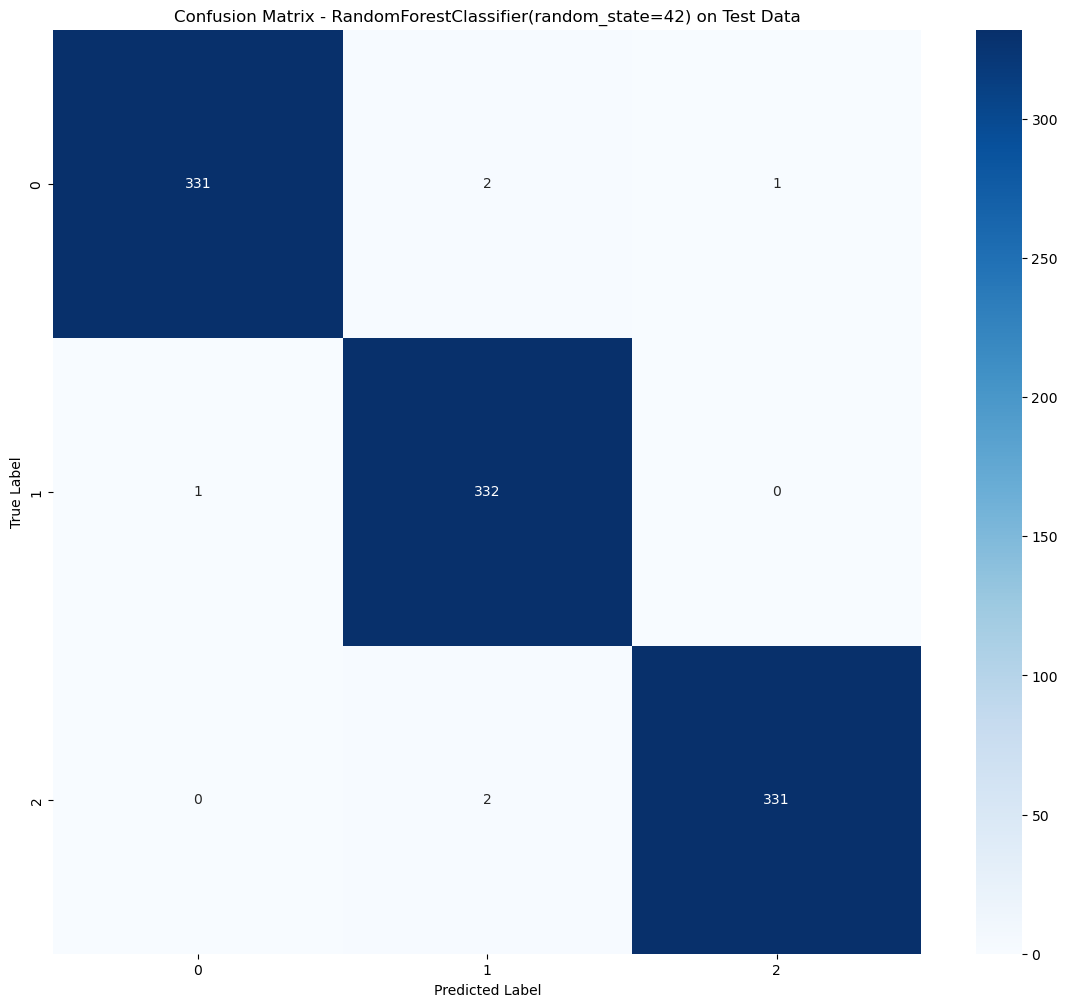

In [106]:
plt.figure(figsize=(14, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model} on Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

### 17. Evaluate all the models on the test set

In [115]:
all_model_test_performance = {}
for name, model_info in results.items():
    model = model_info['model']
    test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, test_pred)
    test_class_report = classification_report(y_test, test_pred, output_dict=True)

    all_model_test_performance[name] = {
        'Test Accuracy': test_acc,
        'Test Precision': test_class_report['macro avg']['precision'],
        'Test Recall': test_class_report['macro avg']['recall'],
        'Test F1-score': test_class_report['macro avg']['f1-score']
    }
test_comparison_df = pd.DataFrame(all_model_test_performance).T
print("\nModel Comparison on Test Dataset:")
print(test_comparison_df)


Model Comparison on Test Dataset:
                   Test Accuracy  Test Precision  Test Recall  Test F1-score
Decision Tree              0.840        0.850074     0.840131       0.839454
Random Forest              0.994        0.994024     0.994003       0.994003
Gradient Boosting          0.882        0.881867     0.881972       0.881892
SVM                        0.473        0.576320     0.472676       0.396542
KNN                        0.903        0.902956     0.902978       0.902881


In [119]:
test_best_model = test_comparison_df['Test F1-score'].idxmax()
print(f"Best model on test data: {test_best_model}")

Best model on test data: Random Forest


# Step 4: Develop Rules for Machine Learning Model

In [134]:
sp_features = [col for col in train_df.columns if col.endswith('SP') and col != 'Class']

sp_features

['FFTE Feed tank level SP',
 'FFTE Production solids SP',
 'FFTE Steam pressure SP',
 'TFE Out flow SP',
 'TFE Production solids SP',
 'TFE Vacuum pressure SP',
 'TFE Steam pressure SP',
 'FFTE Feed flow SP',
 'FFTE Out steam temp SP']

In [151]:
X_sp_df = train_df[sp_features]
y_sp_df = train_df['Class']

X_sp_encoded_df = pd.get_dummies(X_sp_df, drop_first=True)

X_sp_df = X_sp_encoded_df

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model = dt_model.fit(X_sp_df, y_sp_df)

tree_rules = export_text(dt_model, feature_names=list(X_sp_df.columns))
print("\nDecision Tree Rules: ")
print(tree_rules)


Decision Tree Rules: 
|--- FFTE Feed flow SP <= 10198.77
|   |--- FFTE Feed flow SP <= 9231.11
|   |   |--- TFE Out flow SP <= 2173.78
|   |   |   |--- FFTE Feed tank level SP_50.0 <= 0.50
|   |   |   |   |--- TFE Production solids SP <= 68.69
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- TFE Production solids SP >  68.69
|   |   |   |   |   |--- class: 1
|   |   |   |--- FFTE Feed tank level SP_50.0 >  0.50
|   |   |   |   |--- FFTE Feed flow SP <= 9200.68
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- FFTE Feed flow SP >  9200.68
|   |   |   |   |   |--- class: 1
|   |   |--- TFE Out flow SP >  2173.78
|   |   |   |--- FFTE Production solids SP <= 41.31
|   |   |   |   |--- TFE Out flow SP <= 2507.03
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- TFE Out flow SP >  2507.03
|   |   |   |   |   |--- class: 1
|   |   |   |--- FFTE Production solids SP >  41.31
|   |   |   |   |--- TFE Production solids SP <= 68.95
|   |   |   |   |   |--- class: 0
|   |   |   |